## Lab 4: Generating CDFs

**Names:** Hannah Sweazey, Hannah Dykens, Tejas Reddy, Susanna Huang

In [30]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [31]:
def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_vs_cdf(samples, cdf, grid=None, title="", xlabel="", discrete=False, logx=False):
    x, y = ecdf_xy(samples)
    fig, ax = plt.subplots()
    ax.step(x, y, where="post", lw=2, label="simulation ECDF")

    if grid is None:
        lo, hi = np.quantile(x, [0.001, 0.999])
        grid = np.linspace(lo, hi, 400)
    if discrete:
        ax.step(grid, cdf(grid), where="post", lw=2, label="scipy CDF")
    else:
        ax.plot(grid, cdf(grid), lw=2, label="scipy CDF")

    if logx:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cumulative probability")
    ax.legend()
    return ax


def show_quantiles(samples, dist, probs=(0.1, 0.25, 0.5, 0.75, 0.9)):
    return pd.DataFrame({
        "p": probs,
        "simulation": np.quantile(samples, probs),
        "scipy": dist.ppf(probs),
    })

## Q1

In [32]:
K = 5
grid = np.linspace(0, 1, K)
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

np.float64(0.5)

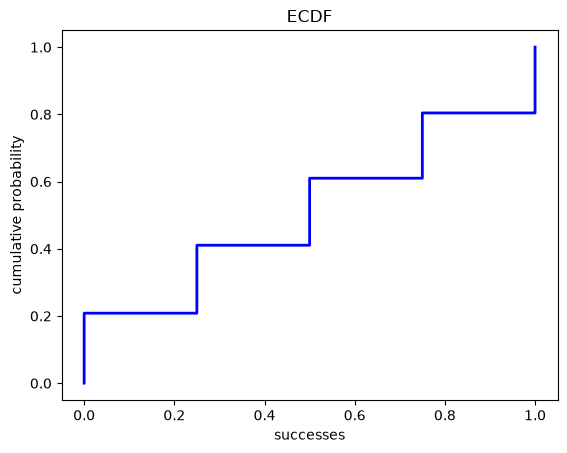

In [33]:
#ECDF with n = 5000 and K = 1
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

In [34]:
K = 100
grid = np.linspace(0, 1, K)
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

np.float64(0.8585858585858587)

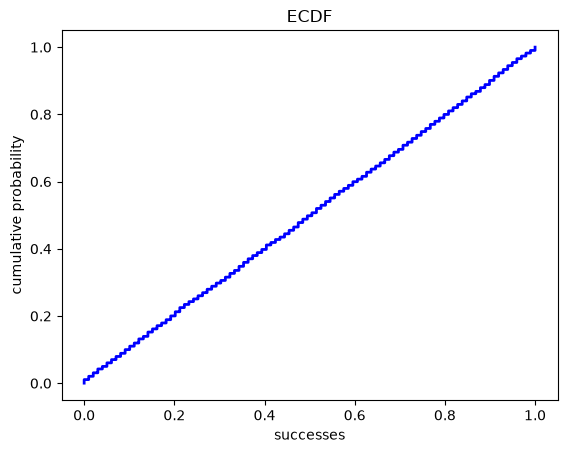

In [35]:
#ECDF with n = 5000 and K = 100
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

In [36]:
K = 10000
grid = np.linspace(0, 1, K)
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

np.float64(0.9527952795279528)

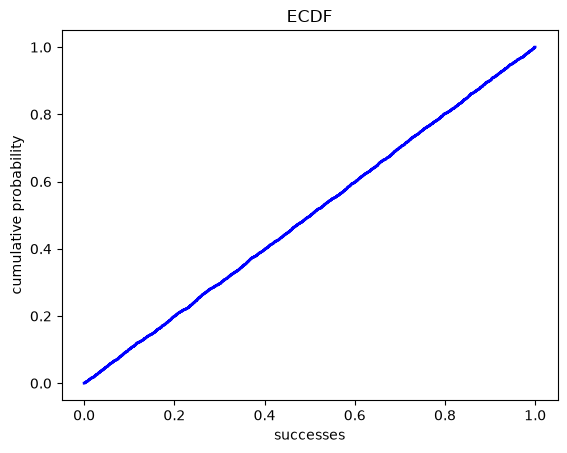

In [37]:
#ECDF with n = 5000 and K = 10,000
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

### 4.
As you increase $K$, the distribution approaches a uniform distribution.

## Q2.


In [38]:
# Using RNG, build a sample with p = 0.1 and a second sample with p = 0.105, each with N = 200. 
N = 32

sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size= N)

trial_pathsA = sampleA.mean() #summing along the trial axis to get cumulative successes
# Make a plot of the running trials and compare.

print(sampleA)
print(trial_pathsA)

[ 0.47439464 -0.03591843 -1.14080435 -0.38223594 -0.64449268  0.41763385
 -0.60532393 -0.67963885 -0.240387    0.16732675  0.94543588 -1.55947012
  0.29155289 -0.56603655 -0.42257826 -1.4151321  -1.10202048 -0.15872733
  1.31762251 -1.20732145  1.01669299  0.12409873 -1.29346899  0.28635907
 -1.32000582  1.53291416 -0.72170589  1.61263854  0.55005355  1.61190907
  0.53463009  0.38672051]
-0.06954015539209052


In [39]:
trial_pathsA * np.sqrt(N)

np.float64(-0.3933785235401077)

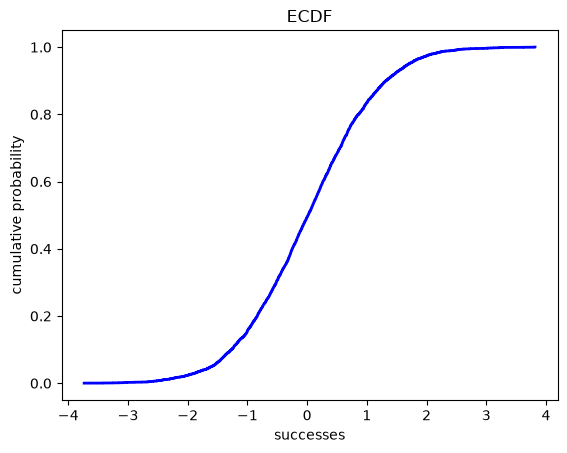

In [40]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,32])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

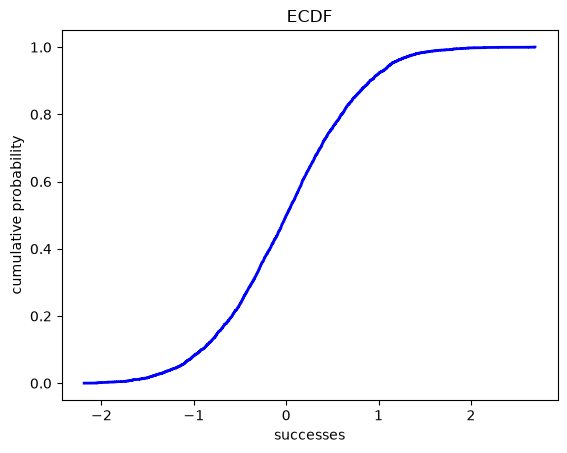

In [41]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,64])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

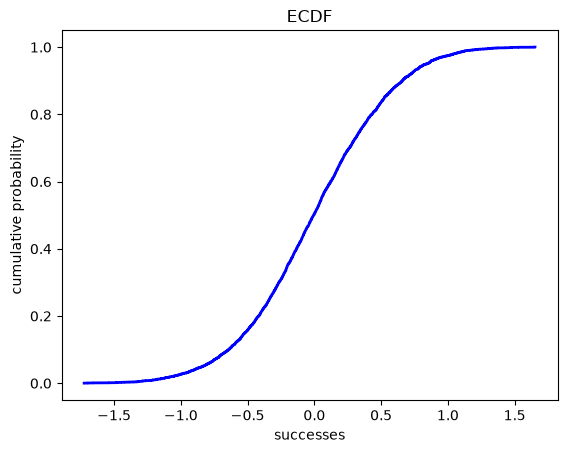

In [42]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,128])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

### 4.

As n increases, this more closely approaches a normal distribution and the x axis range condenses.

## Q3

AI Statement: We used ChatGPT to help us understand our "TypeError: object of type 'float' has no len()" error when using np.random.default_rng().choice().

In [43]:
n = 40
p = 0.5

# count of heads/successes
heads = rng.binomial(n=n, p=p)

# subtracting expected number of heads and divide by standard deviation
zscore = (heads - (n*p)) / np.sqrt((n*p*(1-p)))

zscore


np.float64(0.9486832980505138)

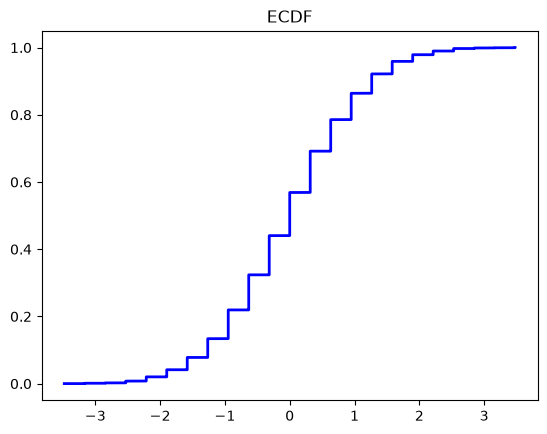

In [44]:
n = 40
p = 0.5
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

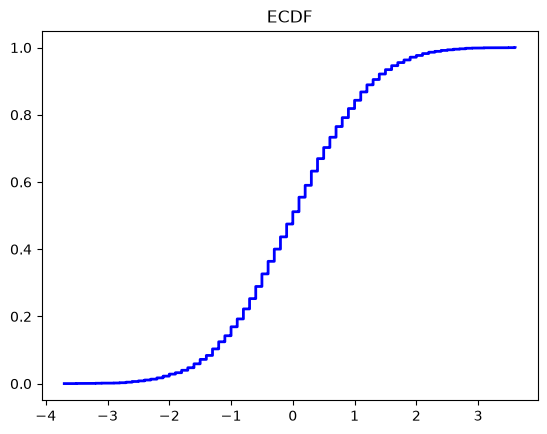

In [45]:
n = 400
p = 0.5
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

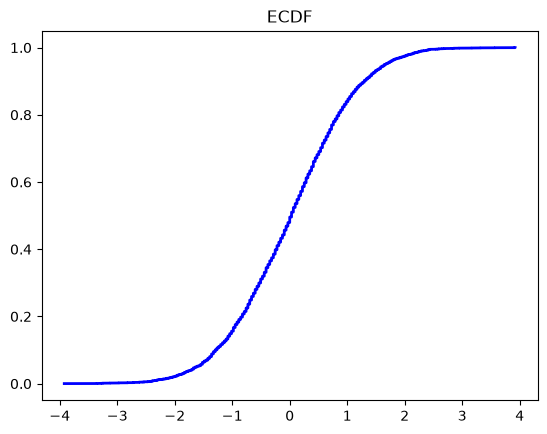

In [46]:
n = 4000
p = 0.5
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

As we increase $n$, this ECDF approaches a Normal Distribution.

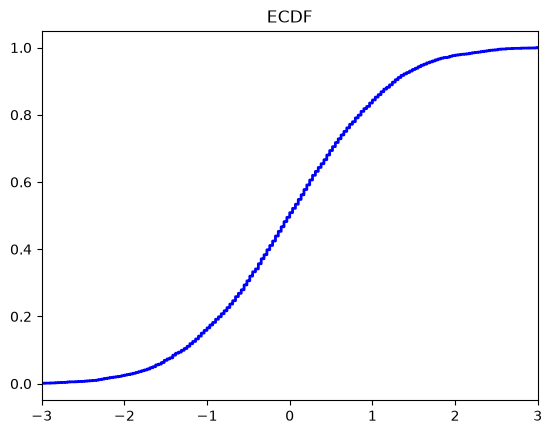

In [52]:
# adjusting p values
n = 4000
p = 0.7
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlim(-3,3)
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

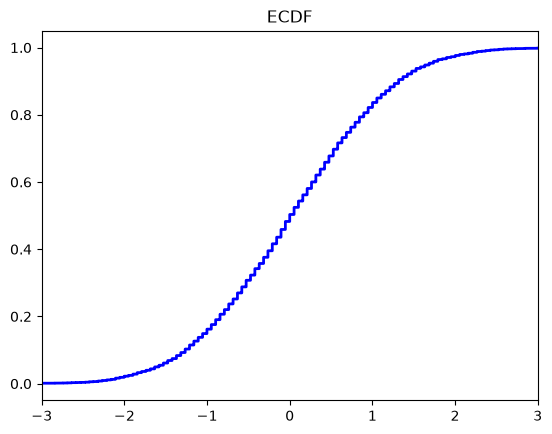

In [53]:
n = 4000
p = 0.1
b = 5000

heads_list = rng.binomial(n=n, p=p, size=b)
z_list = (heads_list - (n*p)) / np.sqrt((n*p*(1-p)))

x, y = ecdf_xy(z_list)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlim(-3,3)
#plt.xlabel("successes")
#plt.ylabel("cumulative probability")
plt.show()

Adjusting $p$ does not change the distribution from a normal distribution as we are essentially standardizing by the new mean and standard deviation.

However, as we adjust $p$ lower we do notice that step sizes become more pronounced in our ECDF because we have less instances of successes.